<p style="font-size:1.25em;"> Ce notebook a pour objectif de fournir rapidement : <br> <strong> Les distances de corrélation associée aux differents pics</strong> <strong>
ainsi que leurs angles issus profils azimutaux</strong> à partir d’un dossier contenant des fichiers <strong>H5</strong>. </p>

## Fonctions principales attendues

- Calcul et plot des intensités moyennes du dossier h5 avec accès aux infos de distance, angle -> SAXSProcessor.plot2D_vsq()

- Extraction des pics de corrélation -> CorrelationDistanceCalculator

- Tracé du profil azimutal pour les valeurs de chaque pics

- Tracé de l'image 2D avec les pics représentés par des cercles.

- Estimation des distances de corrélation dans les directions azimuthales principales (à partir des profils de l' étape 3)

In [29]:
%matplotlib widget
from saxsprocessor import SAXSProcessor
from correlationdistancecalculator import CorrelationDistanceCalculator
from utilities_SWING import *
from utilities import *
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings

# Supprimer le warning OptimizeWarning
warnings.filterwarnings('ignore', category=UserWarning, message='.*Covariance.*')
warnings.filterwarnings('ignore', message='.*Covariance of the parameters could not be estimated.*')

## Data selection

Ici j'importe des data LGC, et je prévois la même chose pour des data SWING.
Il suffira de supprimer la 1ere cellule et de décommenter la 2nde.
La 1ere me sert de test.
La 2nde servira en production.

# LGC data (example)

frame_numbers = np.arange(20,26,2)
path = 'C:/Users/lisab/aSAXS/Synchrotron/Donnees/theo/CelluleMagnetique_CapPlatvd_00036-00037.edf'
mask = 'C:/Users/lisab/aSAXS/Synchrotron/Donnees/theo/mask.edf'


'''filelist=[]
for frame in frame_numbers:
    file_pattern = os.path.join(path, f'*{frame:05d}-{frame+1:05d}*.edf')
    matched_files = glob.glob(file_pattern)
    filelist.extend(matched_files)
print(f"Fichiers trouvés: ")
for file in filelist:
    print(file)

# compute average intensity
total_int = []
for file in filelist:
    
    proc = SAXSProcessor(file, mask = mask, instrument='LGC') 
    total_int.append(proc.data)

mean_int=np.mean(total_int,axis=0)'''



In [30]:

instrument='SWING'

mask = 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/mask_pyfai.edf'
file = 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/lacroix_00109_2026-02-06_03-03-47.nxs'
reference = 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/lacroix_00148_2026-02-06_06-55-44.nxs'
output_dir='./test_output/'
os.makedirs(output_dir,exist_ok=True)


proc = SAXSProcessor(instrument=instrument,reference_file= reference, file=file, mask=mask)

position moteur :
{'X_start': array([37.7002]), 'X_end': array([38.1501]), 'Z_start': array([40.8001]), 'Z_end': array([41.2497])}
{'X_start': array([37.7002]), 'X_end': array([38.1501]), 'Z_start': array([40.8001]), 'Z_end': array([41.2497])}
step :
[0.04499]
[0.04496]
1
Raw data shape: (10, 10, 1083, 1035)
info
1083
1035
position moteur :
{'X_start': array([36.4998]), 'X_end': array([38.6997]), 'Z_start': array([39.4997]), 'Z_end': array([40.9])}
{'X_start': array([36.4998]), 'X_end': array([38.6997]), 'Z_start': array([39.4997]), 'Z_end': array([40.9])}
step :
[0.183325]
[0.1750375]
1
Raw data shape: (12, 8, 1083, 1035)
info
1083
1035
No motor positions provided. Update filereaders.py if required
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Optimized k factor for reference subtraction: 2.218618
(1083, 1035)


## Plot 2D image

In this plot, the cursor gives polar coordinates of the diffraction peaks.
It can be useful for indexing

✅ SAXS image saved: C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/saxs_images/S0032_M0048_Img_109.png


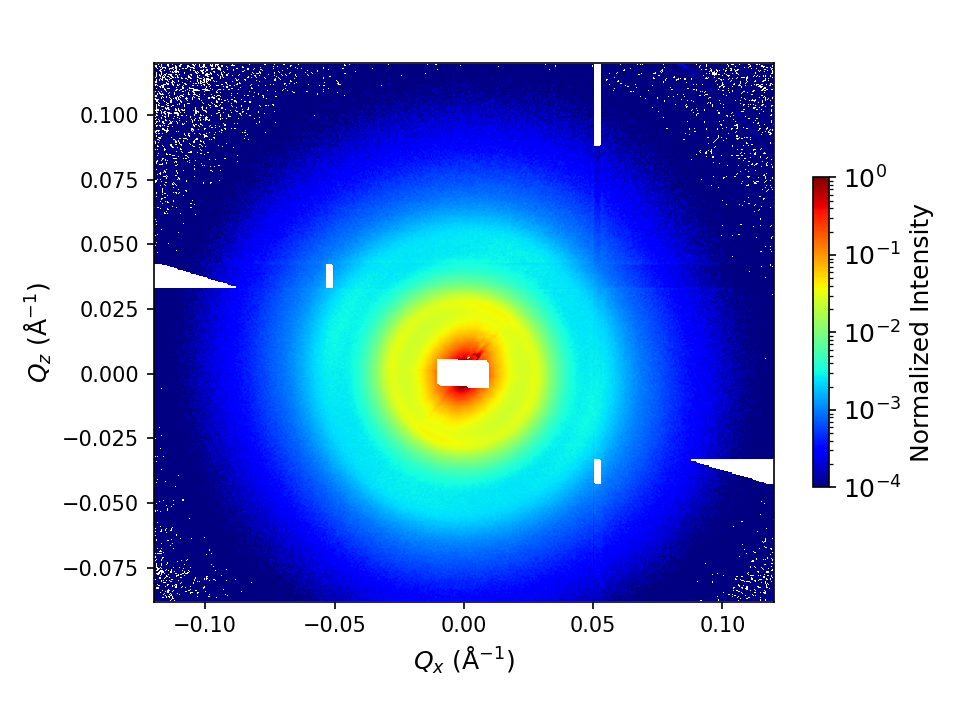

In [31]:
proc.plot2d_vsq(q_range=[0,0.12])

## Extract radial and azimuthal profiles



### 1.Extraction du profil radial

-> Définition du nombre de pics d'intérêt

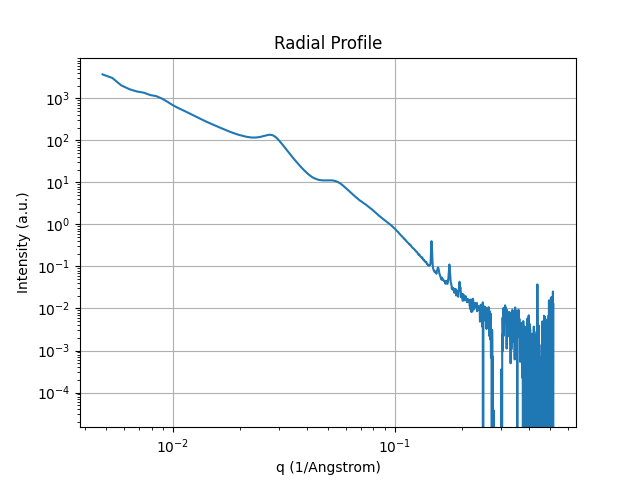

In [32]:
q,I = proc.extract_radial_profile(width=360)

# make loglog plot
plt.figure()
plt.loglog(q, I)
plt.xlabel('q (1/Angstrom)')
plt.ylabel('Intensity (a.u.)')
plt.title('Radial Profile')
plt.grid(True)
plt.show()

***Définition du nombre de pics et du q_range d'intérêt***

On observe 6 pics dans la plage de q [0.03,0.125]

### 2. Extract relevant azimuthal profiles - 3 étapes

Ici on utilise 3 fonctions séparées pour mieux contrôler le workflow :

**Étape 1** : `corr.compute_correlation_distances()` - Détection et affinement des pics
**Étape 2** : `extract_and_plot_azimuthal_profiles()` - Extraction des profils azimutaux
**Étape 3** : `plot_2d_with_peaks()` - Affichage 2D avec cercles des pics


In [ ]:

# ÉTAPE 1 : Détection avec sliders interactifs
get_results = detect_peaks_hybrid_interactive(
    proc,
    nb_peaks_init=3,
    qmin_init=0.01,
    qmax_init=0.2,
    fit_window_width_init=1,
    prominence=0.1,
    distance_pts=20,
    subtract_power_law_init=True
    )



Output()

In [60]:
# Après avoir ajusté les sliders, récupérer les résultats
results_dict = get_results()
distances = results_dict['distances']
distances_std = results_dict['distances_std']
hybrid_results = results_dict['hybrid_results']
peaklist = results_dict['peaklist']
width_used = results_dict['width']
azimuth_used = results_dict['azimuth']


In [62]:


# Afficher le dictionnaire complet de résultats pour inspection
# from pprint import pprint
# pprint(results_dict)

print(f"Width utilisé: {width_used}°, Azimuth utilisé: {azimuth_used}°")

# ÉTAPE 2 : Ajuster les paramètres de détection avec widgets
# Utiliser les sliders ci-dessous pour ajuster smooth_sigma, peak_prominence, et peak_distance
# Les résultats se mettront à jour en temps réel

if width_used == 360:
    extract_and_plot_azimuthal_profiles_interactive(
        proc,
        peaklist,
        threshold=0.05,
        smooth_init=5,
        width_init=10,
        prominence_init=0.3,
        distance_init=20,
        apply_mirror=True,
        output_dir=None)
else:
    print(f"L'angle utilisé sera celui utilisé pour l'extraction azimutale: {azimuth_used}°")


Width utilisé: 45°, Azimuth utilisé: -90°
L'angle utilisé sera celui utilisé pour l'extraction azimutale: -90°


In [ ]:
'''print(proc.azimuthal_results)

# SAUVEGARDE : Exporter les résultats SPV dans un fichier CSV
csv_file = save_azimuthal_profiles_to_csv(
     proc.azimuthal_results,
    proc=proc,
    hybrid_results=hybrid_results,
    tolerance=5.0,
    verbose=True)'''

AttributeError: 'SAXSProcessor' object has no attribute 'azimuthal_results'

In [63]:
# ÉTAPE 3 : Affichage 2D avec pics affinés

def round_angle_to_nominal(angle, tolerance=5.0):
    nominal_angles = [-180,-135,-90,-45,0,45,90,135,180]
    for nominal in nominal_angles:
        if abs(angle - nominal) <= tolerance:
            return nominal
    return round(angle, 2)

peak_list = []

if width_used == 360:
    # Utiliser les résultats azimutaux (ÉTAPE 2 exécutée)
    for q_value, angles_list in zip(
            proc.azimuthal_results["q_values"],
            proc.azimuthal_results["phi_maxima"]
        ):
        for angle in angles_list:
            # Convert q → d = 2π/q
            d_value = 0.2 * np.pi / q_value

            peak_list.append((
                q_value,                       # distance (Å-1)
                round_angle_to_nominal(angle),  # rounded chi angle (deg)
                d_value,                        # distance (nm)
            ))
else:
    # ÉTAPE 2 non exécutée: utiliser azimuth_used comme angle pour chaque pic
    for q_value in peaklist:
        # Convert q → d = 2π/q
        d_value = 0.2 * np.pi / q_value

        peak_list.append((
            q_value,                       # distance (Å-1)
            round_angle_to_nominal(azimuth_used),  # angle from detection (deg)
            d_value,                        # distance (nm)
        ))
    print(f"Utilisation de l'azimuth détecté ({azimuth_used}°) pour tous les pics")

# Supprimer les doublets
peak_list = sorted(list(set(peak_list)))

Utilisation de l'azimuth détecté (-90°) pour tous les pics


✅ SAXS image saved: C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/saxs_images/S0033_M0041_Img_102.png


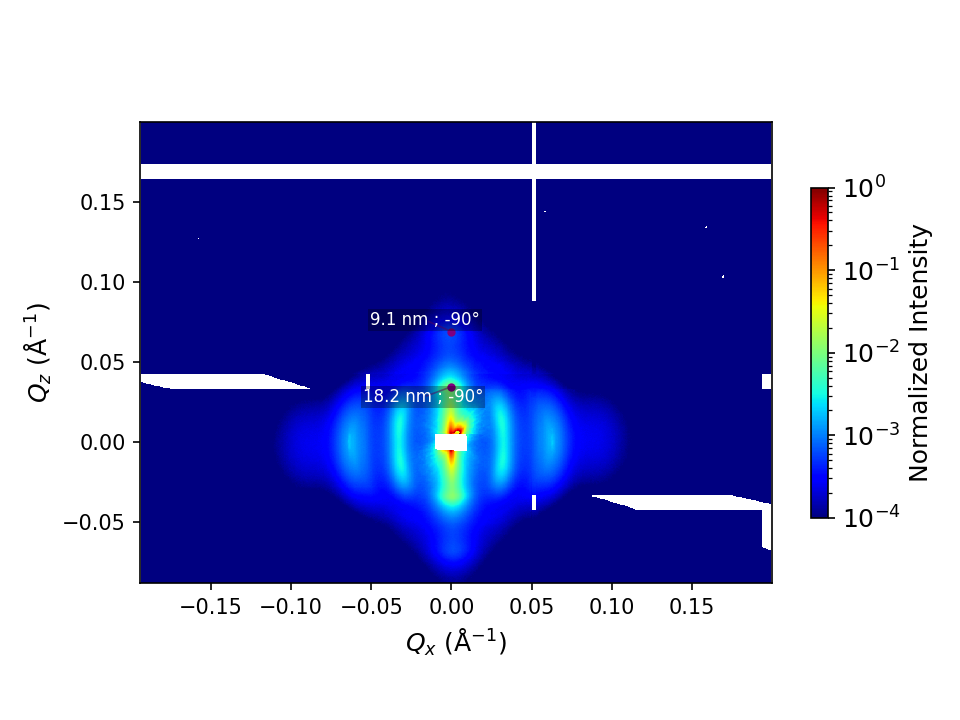

0.03461205741550046 -90 18.15316908715678
0.06903861699320375 -90 9.10097215272738


In [64]:
proc.plot2d_vsq(q_range=[0,0.2],peak_list=peak_list)

for q_val, chi_deg, d_val in peak_list:
    print(q_val, chi_deg, d_val)